# Playlist Data Exploration

Exploring the Anna's Archive Spotify playlist dataset (6.6M playlists, 1.7B track entries) to determine filtering thresholds for BPR matrix factorization training.

In [5]:
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import random
from autoencoder.db import get_connection
from autoencoder.db import get_tables
from autoencoder.db import get_columns
from autoencoder.db import head_table


DATABASE_PATH = Path.home() / "HDD/Datasets/annas_archive_spotify_2025_07/spotify_clean_playlists.sqlite3"

## Connect to Databases

Create separate connections to each database. Connections are instant with native sqlite3.

In [6]:
conn  = get_connection(DATABASE_PATH)
print("Connected to database")
conn.row_factory = sqlite3.Row

Connected to database


## Schema & row counts

In [8]:
for table in get_tables(conn):
    columns = get_columns(conn, table)
    col_str = ", ".join(f"{name} ({dtype})" for name, dtype in columns)
    print(f"  {table}: {col_str}")

  playlist_images: playlist_rowid (INTEGER), width (INTEGER), height (INTEGER), url (TEXT)
  playlist_tracks: playlist_rowid (INTEGER), position (INTEGER), is_episode (INTEGER), track_rowid (INTEGER), id_if_not_in_tracks_table (TEXT), added_at (INTEGER), added_by_id (TEXT), primary_color (TEXT), video_thumbnail_url (TEXT), is_local (INTEGER), name_if_is_local (TEXT), uri_if_is_local (TEXT), album_name_if_is_local (TEXT), artists_name_if_is_local (TEXT), duration_ms_if_is_local (INTEGER)
  playlists: rowid (INTEGER), id (TEXT), snapshot_id (TEXT), fetched_at (INTEGER), name (TEXT), description (TEXT), collaborative (INTEGER), public (INTEGER), primary_color (TEXT), owner_id (TEXT), owner_display_name (TEXT), followers_total (INTEGER), tracks_total (INTEGER)


In [3]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
for t in tables["name"]:
    count = conn.execute(f"SELECT COUNT(*) FROM [{t}]").fetchone()[0]
    print(f"{t}: {count:,} rows")

playlist_images: 11,326,423 rows
playlist_tracks: 1,698,443,099 rows
playlists: 6,608,769 rows


# Sample data

In [10]:
def sample_table(
    conn: sqlite3.Connection,
    table: str,
    n: int = 1000,
) -> pd.DataFrame:
    """
    Get a random sample from a table using ROWID-based sampling.

    This is fast even on huge tables because it:
    1. Gets max ROWID (uses index, instant)
    2. Generates random ROWIDs in Python
    3. Fetches only those specific rows
    """
    # Get max rowid
    cursor = conn.execute(f"SELECT MAX(rowid) FROM {table}")
    max_rowid = cursor.fetchone()[0]

    if max_rowid is None or max_rowid == 0:
        return pd.DataFrame()

    # Generate random rowids (sample more than needed to account for gaps)
    sample_size = min(n * 3, max_rowid)
    random_rowids = random.sample(range(1, max_rowid + 1), sample_size)

    # Fetch rows with those rowids
    placeholders = ",".join(["?"] * len(random_rowids))
    query = f"SELECT * FROM {table} WHERE rowid IN ({placeholders}) LIMIT {n}"
    return pd.read_sql_query(query, conn, params=random_rowids)

In [11]:
sample_table(conn, "playlists", n=5)

,rowid,id,snapshot_id,fetched_at,name,description,collaborative,public,primary_color,owner_id,owner_display_name,followers_total,tracks_total
0,2464254,1jH5gpw0mpaEGtnSL7KNbh,AAAAPN+nllbWz46dWEKJjsNYVJgnBQW0,1756944000000,Relax 👌,None,0,1,None,rachelwojtas,Rachel Wojtas,2,26
1,2556320,7DKBZBbFcyuAc28ayCXs7N,AAAAs3PF2nWCRUJabGDe85eloT5N4gSP,1756944000000,hunters ridge redneck golf shop,None,0,1,None,2daw8xplvei0c1xgimhuuwyqz,emilee caroline,0,1115
2,3463321,37i9dQZF1EIgsRQOLDXC0P,AAAAAMOuIRplQIzQgPcGFV3IUoB8EyqO,1757548800000,Lonely Horns Mix,Lonely Horns music picked just for you,0,1,None,spotify,Spotify,0,50
3,3682883,37i9dQZF1EIWsLJu8woMtu,AAAAAGzrkXuVr+rbMbYCZ1JcM/aA76kR,1759363200000,Imminent Sonic Destruction Mix,<a href=spotify:playlist:37i9dQZF1EIZaeM9AJvat...,0,1,None,spotify,Spotify,0,50
4,3699972,37i9dQZF1E4zyjKrDIgjCD,aMrzsQAAAAB0jnIDqZ8WMAwKRaUCzDHb,1757548800000,Isla Campbell Radio,"With Madilyn Mei, Fulton Lee, Luma Nyah and more",0,1,None,spotify,Spotify,0,50


In [13]:
sample_table(conn, "playlist_tracks", n=5)

,playlist_rowid,position,is_episode,track_rowid,id_if_not_in_tracks_table,added_at,added_by_id,primary_color,video_thumbnail_url,is_local,name_if_is_local,uri_if_is_local,album_name_if_is_local,artists_name_if_is_local,duration_ms_if_is_local
0,199291,1275,0,5119335,None,1699201520,a9n0sewbvinlcf538pdcyoe9r,None,None,0,None,None,None,None,None
1,339131,156,0,139853902,None,1721929960,rj8dc1blytm1f6dk3akwp9a34,None,None,0,None,None,None,None,None
2,1033770,6,0,18795,None,1625720899,lv3gqdxzelwgv5k0vs7togku2,None,None,0,None,None,None,None,None
3,1398379,316,0,103766199,None,1714081064,dinushkasilva01,None,None,0,None,None,None,None,None
4,1708839,382,0,59044,None,1722200434,kansas_elite18,None,None,0,None,None,None,None,None


## Playlist statistics

In [17]:
playlists = pd.read_sql(
    conn,
    """
    SELECT followers_total, tracks_total, collaborative, public
    FROM playlists
    """
)
playlists.describe()

,followers_total,tracks_total,collaborative,public
count,6.608471e+06,6.608769e+06,6.608769e+06,6608769.0
mean,1.039106e+03,2.569985e+02,3.378995e-03,1.0
std,3.654896e+04,5.857018e+02,5.803084e-02,0.0
min,0.000000e+00,0.000000e+00,0.000000e+00,1.0
25%,0.000000e+00,5.000000e+01,0.000000e+00,1.0
50%,1.000000e+00,7.500000e+01,0.000000e+00,1.0
75%,8.000000e+00,2.270000e+02,0.000000e+00,1.0
max,3.524848e+07,1.292400e+04,1.000000e+00,1.0


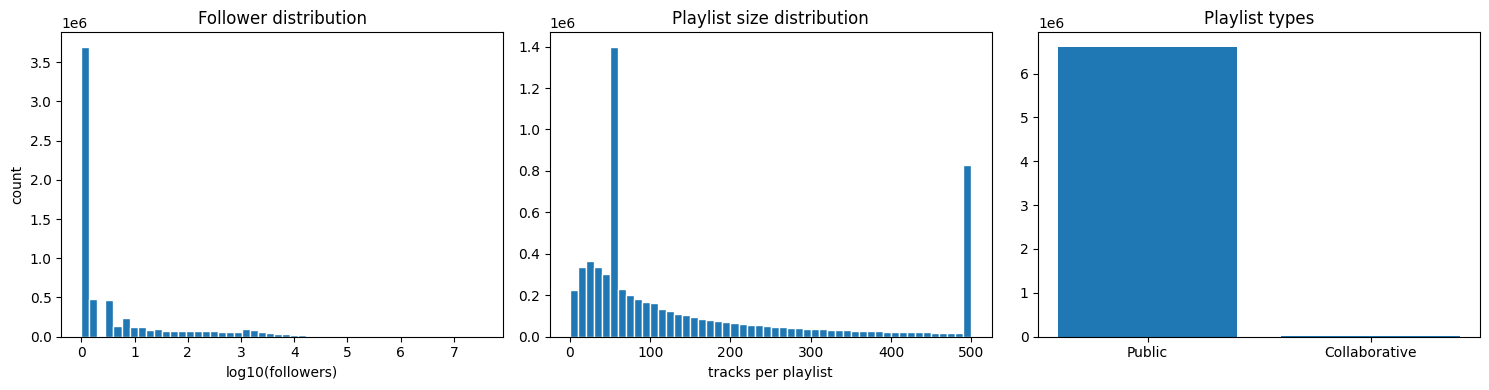

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(np.log10(playlists["followers_total"].clip(lower=1)), bins=50, edgecolor="white")
axes[0].set_xlabel("log10(followers)")
axes[0].set_ylabel("count")
axes[0].set_title("Follower distribution")

axes[1].hist(playlists["tracks_total"].clip(upper=500), bins=50, edgecolor="white")
axes[1].set_xlabel("tracks per playlist")
axes[1].set_title("Playlist size distribution")

axes[2].bar(["Public", "Collaborative"], [
    playlists["public"].sum(),
    playlists["collaborative"].sum(),
])
axes[2].set_title("Playlist types")

plt.tight_layout()
plt.show()

## Filtering threshold analysis

How many playlists and interactions survive at various follower thresholds?

In [18]:
thresholds = [1000, 2000, 5000, 10_000, 20_000, 50_000, 100_000]
followers = playlists["followers_total"]
tracks_total = playlists["tracks_total"]

rows = []
for t in thresholds:
    mask = followers >= t
    n_pl = mask.sum()
    est_interactions = tracks_total[mask].sum()
    rows.append({"min_followers": t, "playlists": n_pl, "est_interactions": est_interactions})

threshold_df = pd.DataFrame(rows)
threshold_df["playlists_fmt"] = threshold_df["playlists"].map("{:,}".format)
threshold_df["interactions_fmt"] = threshold_df["est_interactions"].map("{:,}".format)
threshold_df

,min_followers,playlists,est_interactions,playlists_fmt,interactions_fmt
0,1000,471572,73226887,"471,572","73,226,887"
1,2000,278729,43445612,"278,729","43,445,612"
2,5000,133402,20470208,"133,402","20,470,208"
3,10000,74082,11064678,"74,082","11,064,678"
4,20000,39772,5715518,"39,772","5,715,518"
5,50000,16932,2267764,"16,932","2,267,764"
6,100000,8752,1090705,"8,752","1,090,705"


## Data quality: episodes, local files, null track_rowids

These queries hit the 1.7B-row playlist_tracks table. They may be slow — we sample or use indexed columns.

In [19]:
quality = pd.read_sql("""
    SELECT 
        COUNT(*) as total,
        SUM(is_episode) as episodes,
        SUM(is_local) as local_files,
        SUM(track_rowid IS NULL) as null_track_rowids
    FROM playlist_tracks
""", conn)
quality

,total,episodes,local_files,null_track_rowids
0,1698443099,1363945,3346851,8430451


## Track coverage

How many unique tracks appear in the playlist data, and how many overlap with our existing pop>40 training set?

In [ ]:
# Unique tracks in playlist data (this may be slow on the full table)
n_unique_tracks = conn.execute("""
    SELECT COUNT(DISTINCT track_rowid) 
    FROM playlist_tracks 
    WHERE track_rowid IS NOT NULL AND is_episode = 0 AND is_local = 0
""").fetchone()[0]
print(f"Unique tracks in playlist data: {n_unique_tracks:,}")

In [ ]:
# Load our existing training track_rowids for overlap check
training_data = pd.read_parquet(
    Path("..") / "data/engineered/training_pop40_genres.parquet",
    columns=["track_rowid"],
)
training_track_ids = set(training_data["track_rowid"])
print(f"Existing training set: {len(training_track_ids):,} tracks")

## Filtered co-occurrence stats

Pick a threshold from the analysis above and compute detailed stats for the filtered subset.

In [ ]:
# --- adjust this after reviewing the threshold table above ---
FOLLOWER_THRESHOLD = 5000

filtered_playlists = set(
    playlists.index[playlists["followers_total"] >= FOLLOWER_THRESHOLD]
)

In [ ]:
# Use SQL to get stats for the filtered subset
# This joins on the playlists table which has an index on followers_total
filtered_stats = pd.read_sql(f"""
    SELECT 
        COUNT(*) as n_interactions,
        COUNT(DISTINCT pt.playlist_rowid) as n_playlists,
        COUNT(DISTINCT pt.track_rowid) as n_tracks
    FROM playlist_tracks pt
    JOIN playlists p ON pt.playlist_rowid = p.rowid
    WHERE p.followers_total >= {FOLLOWER_THRESHOLD}
      AND pt.is_episode = 0
      AND pt.is_local = 0
      AND pt.track_rowid IS NOT NULL
""", conn)

n_i = filtered_stats["n_interactions"].iloc[0]
n_p = filtered_stats["n_playlists"].iloc[0]
n_t = filtered_stats["n_tracks"].iloc[0]
sparsity = 1 - n_i / (n_p * n_t)

print(f"Follower threshold: >= {FOLLOWER_THRESHOLD:,}")
print(f"Playlists: {n_p:,}")
print(f"Unique tracks: {n_t:,}")
print(f"Interactions: {n_i:,}")
print(f"Sparsity: {sparsity:.6f}")
print(f"Avg tracks/playlist: {n_i / n_p:.1f}")

In [ ]:
conn.close()
print("Done.")